In [1]:
import pandas as pd 
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import networkx as nx
from node2vec import Node2Vec
from sklearn.model_selection import train_test_split
import umap

In [2]:
def plot_umap_results(embedding, labels=None):
    """
    Affiche le scatter plot UMAP.
    Argument: 
        - embedding: le résultat de fit_transform
        - labels: (optionnel) le tableau des opinions (0, 4, -1)
    """
    if labels is None:
        raise ValueError("La fonction a besoin des labels pour colorer le graph. "
                         "Passez 'train_opinions_np' en deuxième argument.")

    plt.figure(figsize=(12, 8))
    
    categories = {
        0: {'color': '#e74c3c', 'label': 'Sceptique'},
        4: {'color': '#3498db', 'label': 'Pro-climat'},
        -1: {'color': '#bdc3c7', 'label': 'Inconnu'}
    }
    
    for val, info in categories.items():
        mask = (labels == val)
        if np.any(mask):
            plt.scatter(
                embedding[mask, 0], 
                embedding[mask, 1], 
                c=info['color'], 
                label=f"{info['label']} ({val})",
                s=8, 
                alpha=0.7
            )

    plt.title("Répartition des opinions (UMAP)", fontsize=16)
    plt.legend(title="Opinions", markerscale=2)
    plt.show()

In [3]:

fichiers_csv=glob.glob(os.path.join('./sampleGraphs', "graph_*.csv"))

print(f"Trouv� {len(fichiers_csv)} fichiers � fusionner.")
liste_df=[]

for fichier in fichiers_csv:
        print(f"Lecture du fichier {fichier}...")
        df=pd.read_csv(fichier)
        liste_df.append(df)

df_global = pd.concat(liste_df, ignore_index=True)
df_grouped=df.groupby(['user_id', 'original_author'])['nb_retweeted'].sum().reset_index()
df_grouped.to_csv('graphe_complet_groupe.csv', index=False)
print(f"Fusion terminée. Taille finale : {len(df_grouped)} lignes.")
#Creation du graphe :


Trouv� 9 fichiers � fusionner.
Lecture du fichier ./sampleGraphs/graph_2022-01-01_to_2022-01-14.csv...
Lecture du fichier ./sampleGraphs/graph_2022-01-08_to_2022-01-21.csv...
Lecture du fichier ./sampleGraphs/graph_2022-01-15_to_2022-01-28.csv...
Lecture du fichier ./sampleGraphs/graph_2022-01-22_to_2022-02-04.csv...
Lecture du fichier ./sampleGraphs/graph_2022-01-29_to_2022-02-11.csv...
Lecture du fichier ./sampleGraphs/graph_2022-02-05_to_2022-02-18.csv...
Lecture du fichier ./sampleGraphs/graph_2022-02-12_to_2022-02-25.csv...
Lecture du fichier ./sampleGraphs/graph_2022-02-19_to_2022-03-04.csv...
Lecture du fichier ./sampleGraphs/graph_2022-02-26_to_2022-03-11.csv...
Fusion terminée. Taille finale : 53830 lignes.


In [4]:
    
G = nx.from_pandas_edgelist(df_grouped, 
                            source='user_id', 
                            target='original_author', 
                            edge_attr='nb_retweeted')



print(f"Le graphe final contient {G.number_of_nodes()} utilisateurs.")
    
    #Exploration :
node2vec=Node2Vec(G, dimensions=32, walk_length=10, num_walks=10, workers=2)

model=node2vec.fit(window=10, min_count=1, batch_words=4)

nodes =list(G.nodes)
embeddings=[model.wv[str(node)] for node in nodes]

pd_save=pd.DataFrame(embeddings, index=nodes)

pd_save.to_csv("embedings.csv")
embeddings = {str(nodes[i]): embeddings[i] for i in range(len(nodes))}

Le graphe final contient 43168 utilisateurs.


Computing transition probabilities:   0%|          | 0/43168 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [4]:
df_nodes = pd.read_csv('Nodes.csv', dtype={'Id': str})
emb = pd.read_csv('embedings.csv') 

In [5]:
# On force la première colonne des embeddings en texte aussi
emb_col_name = emb.columns[0]
emb[emb_col_name] = emb[emb_col_name].astype(float).apply(lambda x: '{:.0f}'.format(x))

In [6]:
# 2. On crée le dictionnaire avec des clés en TEXTE
mapping_dict = {str(k): v for k, v in zip(df_nodes['Id'], df_nodes['modularity_class'])}

In [7]:
# 3. Filtrage propre
labeled = set(df_nodes['Id'].unique())
emb_labeled = emb[emb[emb_col_name].isin(labeled)].reset_index(drop=True)

In [8]:
y_list = []
liste_emb_filtered = emb_labeled.values.tolist()
train, test = train_test_split(liste_emb_filtered, test_size=0.20, random_state=42)

In [9]:
# On crée des versions sans la colonne ID (qui est à l'indice 0)
train_ = [row[1:] for row in train]
test_ = [row[1:] for row in test]
#apprentissage non supervisé
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

# Apprentissage sur la population de 80% avec non supervision
train_embedding = reducer.fit_transform(train_)
test_emb=reducer.transform(test_)
y_list_train = []
for row in train:
    # On transforme l'ID en texte exact, sans virgule ni "e"
    val = '{:.0f}'.format(float(row[0]))
    y_list_train.append(mapping_dict.get(val, -1))

# 3. CRUCIAL : Convertir en tableau NumPy avec un type numérique précis (int64)
train_opinions_np = np.array(y_list_train, dtype=np.int64)

y_list_test = []


for row in test:
    # On transforme l'ID en texte exact, sans virgule ni "e"
    val = '{:.0f}'.format(float(row[0]))
    y_list_test.append(mapping_dict.get(val, -1))

# 3. CRUCIAL : Convertir en tableau NumPy avec un type numérique précis (int64)
test_opinions_np = np.array(y_list_test, dtype=np.int64)

/home/bourenane/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


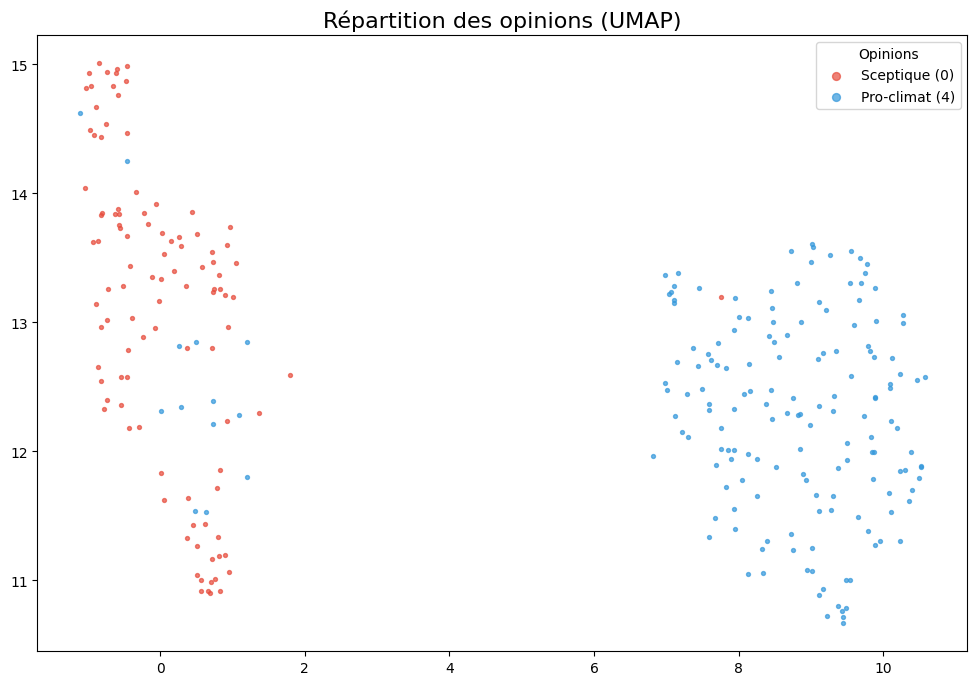

In [10]:
plot_umap_results(train_embedding,train_opinions_np)

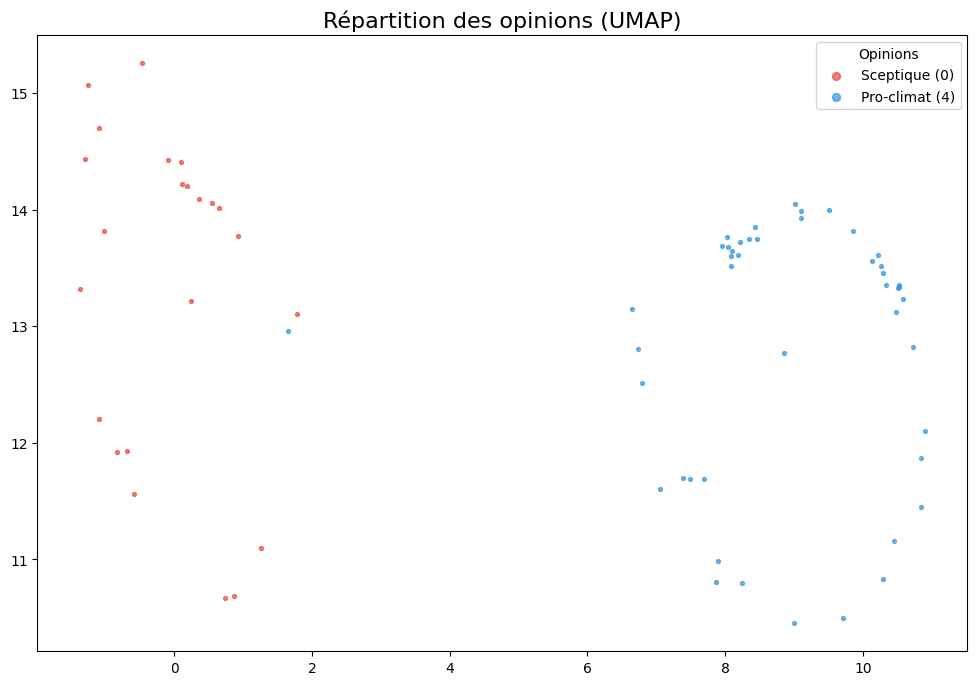

In [11]:
plot_umap_results(test_emb,test_opinions_np)

In [12]:
# Test KNN sur UMAP Non-Supervisé
knn_unsup = KNeighborsClassifier(n_neighbors=5)
knn_unsup.fit(train_embedding, train_opinions_np)
y_pred_unsup = knn_unsup.predict(test_emb)

print("--- RÉSULTATS UMAP SUPERVISÉ ---")
print(f"Accuracy: {accuracy_score(test_opinions_np, y_pred_unsup):.4f}")
print(classification_report(test_opinions_np, y_pred_unsup))

--- RÉSULTATS UMAP SUPERVISÉ ---
Accuracy: 0.9855
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           4       1.00      0.98      0.99        46

    accuracy                           0.99        69
   macro avg       0.98      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69



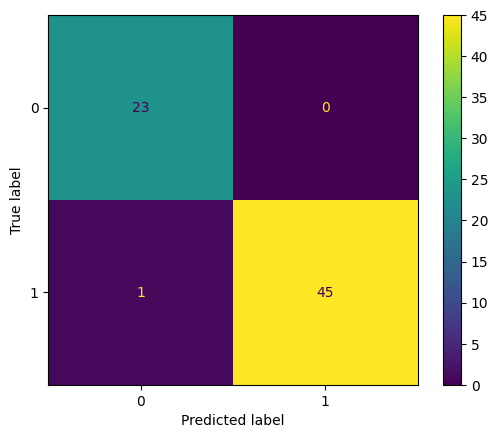

In [13]:

cm=confusion_matrix(test_opinions_np,y_pred_unsup)
d=ConfusionMatrixDisplay(cm)
d.plot()

In [14]:


y_list_train = []
for row in train:
    # On transforme l'ID en texte exact, sans virgule ni "e"
    val = '{:.0f}'.format(float(row[0]))
    y_list_train.append(mapping_dict.get(val, -1))

# 3. CRUCIAL : Convertir en tableau NumPy avec un type numérique précis (int64)
train_opinions_np_tot = np.array(y_list_train, dtype=np.int64)

In [15]:
reducers_tot = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,
    target_weight=0.5  
)
train_embedding_tot = reducers_tot.fit_transform(train_,y=train_opinions_np_tot)
test_emb_tot=reducers_tot.transform(test_)

/home/bourenane/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


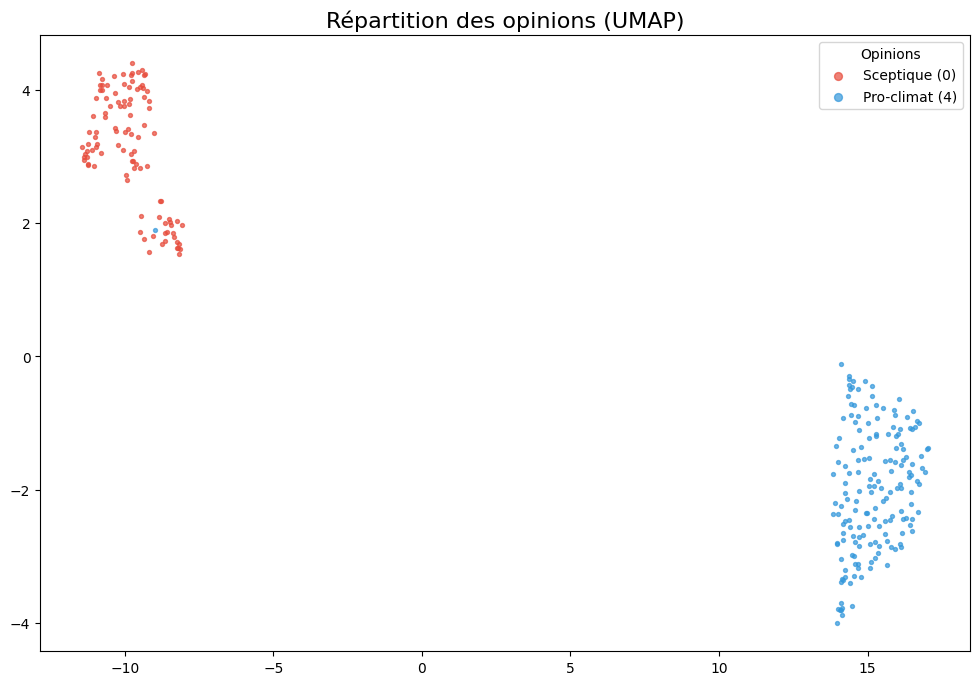

In [16]:
plot_umap_results(train_embedding_tot,train_opinions_np_tot)

In [17]:
y_list_test = []
for row in test:
    # On transforme l'ID en texte exact, sans virgule ni "e"
    val = '{:.0f}'.format(float(row[0]))
    y_list_test.append(mapping_dict.get(val, -1))
                           
test_opinions_np_tot=np.array(y_list_test, dtype=np.int64)

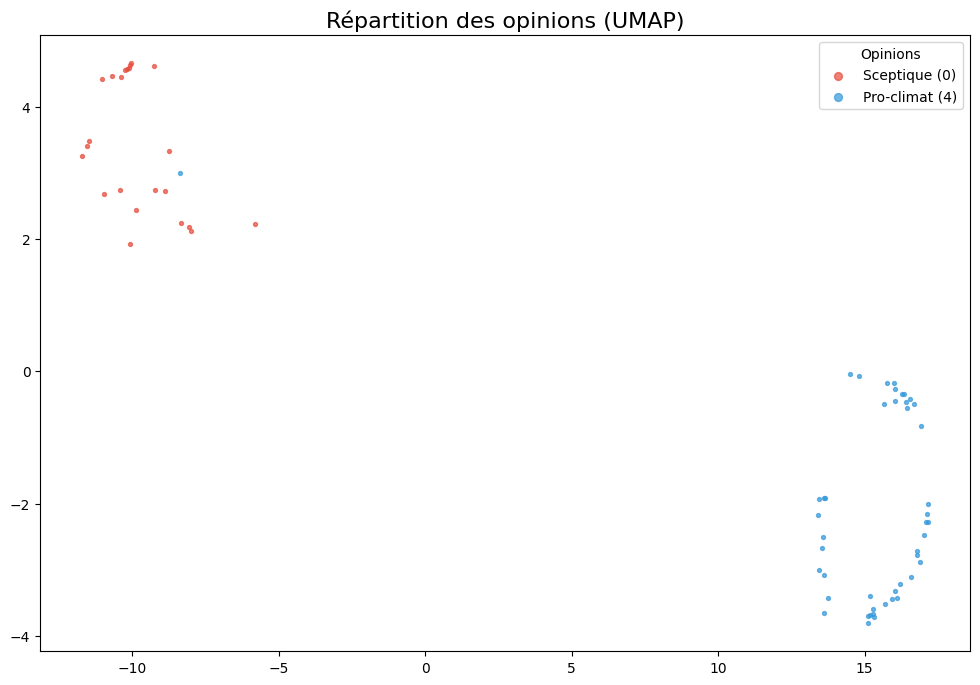

In [18]:
plot_umap_results(test_emb_tot,test_opinions_np_tot)

In [19]:
knn_supper=KNeighborsClassifier(n_neighbors=5)
knn_model=knn_supper.fit(train_embedding_tot,train_opinions_np_tot)
y_pred_sup=knn_model.predict(test_emb_tot)
print(f"Précision sur les personnes connues : {accuracy_score(test_opinions_np_tot, y_pred_sup):.2%}")


Précision sur les personnes connues : 98.55%


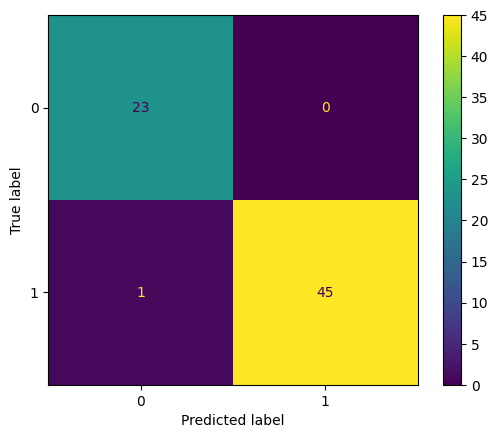

In [20]:
cmSupp=confusion_matrix(test_opinions_np_tot, y_pred_sup)
d2=ConfusionMatrixDisplay(cmSupp)
d2.plot()

In [21]:
#la méthode du barycentre avec changement de coordonnées

In [22]:
mask_scep = (train_opinions_np_tot == 0)
mask_pro = (train_opinions_np_tot == 4)

In [23]:
points_scep = train_embedding_tot[mask_scep]
points_pro = train_embedding_tot[mask_pro]

In [24]:
bary_scep = np.mean(points_scep, axis=0)
bary_pro = np.mean(points_pro, axis=0)

In [25]:
centre_global = (bary_scep + bary_pro) / 2
train_embedding_centre = train_embedding_tot - centre_global

In [26]:
bary_scep_c = bary_scep - centre_global
bary_pro_c = bary_pro - centre_global

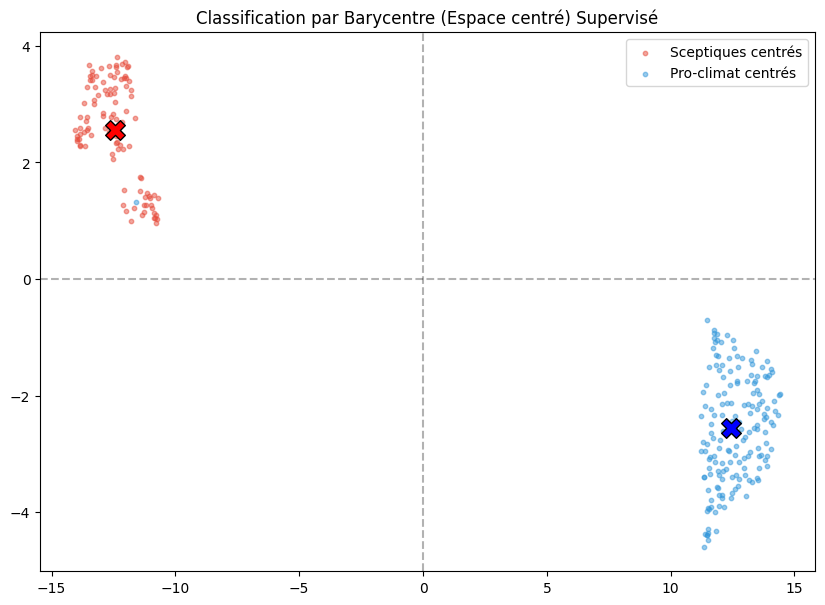

In [27]:
# 4. VISUALISATION
plt.figure(figsize=(10, 7))
plt.scatter(points_scep[:,0] - centre_global[0], points_scep[:,1] - centre_global[1], 
            c='#e74c3c', s=10, alpha=0.5, label='Sceptiques centrés')
plt.scatter(points_pro[:,0] - centre_global[0], points_pro[:,1] - centre_global[1], 
            c='#3498db', s=10, alpha=0.5, label='Pro-climat centrés')

# Affichage des centres
plt.scatter(bary_scep_c[0], bary_scep_c[1], c='red', marker='X', s=200, edgecolors='black')
plt.scatter(bary_pro_c[0], bary_pro_c[1], c='blue', marker='X', s=200, edgecolors='black')

plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Classification par Barycentre (Espace centré) Supervisé")
plt.legend()
plt.show()

In [28]:
def calculer_distance(p1, p2):

    return np.sqrt(np.sum((p1 - p2)**2))

def predire_classe(point, b_scep, b_pro):
    dist_scep = calculer_distance(point, b_scep)
    dist_pro = calculer_distance(point, b_pro)
    
    # On retourne 0 si plus proche de sceptique, sinon 4
    if dist_scep < dist_pro:
        return 0
    else:
        return 4

In [29]:

predictions = []
for point in test_emb_tot:
    predictions.append(predire_classe(point, bary_scep, bary_pro))

predictions = np.array(predictions)


nb_correct = np.sum(predictions == test_opinions_np_tot)
accuracy_manuelle = nb_correct / len(test_opinions_np_tot)

print(f"Nombre de points bien classés : {nb_correct} sur {len(test_opinions_np_tot)}")
print(f"Précision manuelle : {accuracy_manuelle * 100:.2f}%")

Nombre de points bien classés : 68 sur 69
Précision manuelle : 98.55%


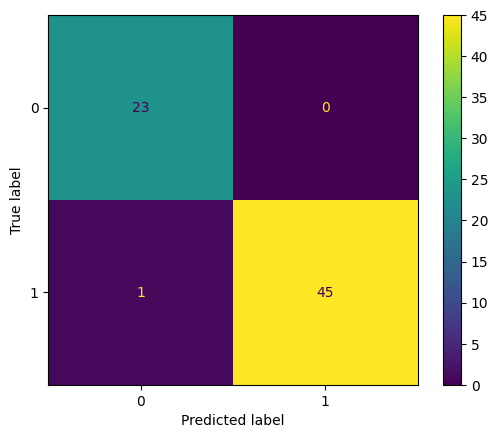

In [30]:
cm=confusion_matrix(test_opinions_np_tot,predictions)
d3=ConfusionMatrixDisplay(cm)
d3.plot()

In [31]:
#Non Supervise

In [32]:
points_scep_Usup = train_embedding[train_opinions_np==0]
points_pro_Usup = train_embedding[train_opinions_np==4]

In [33]:
bary_scepu_Usup = np.mean(points_scep_Usup, axis=0)
bary_pro_Usup = np.mean(points_pro_Usup, axis=0)

In [34]:
centre_global = (bary_scepu_Usup + bary_pro_Usup) / 2
train_embedding_centre_Usup = train_embedding - centre_global

In [35]:
bary_scep_c_Usup = bary_scepu_Usup - centre_global
bary_pro_c_Usup = bary_pro_Usup - centre_global

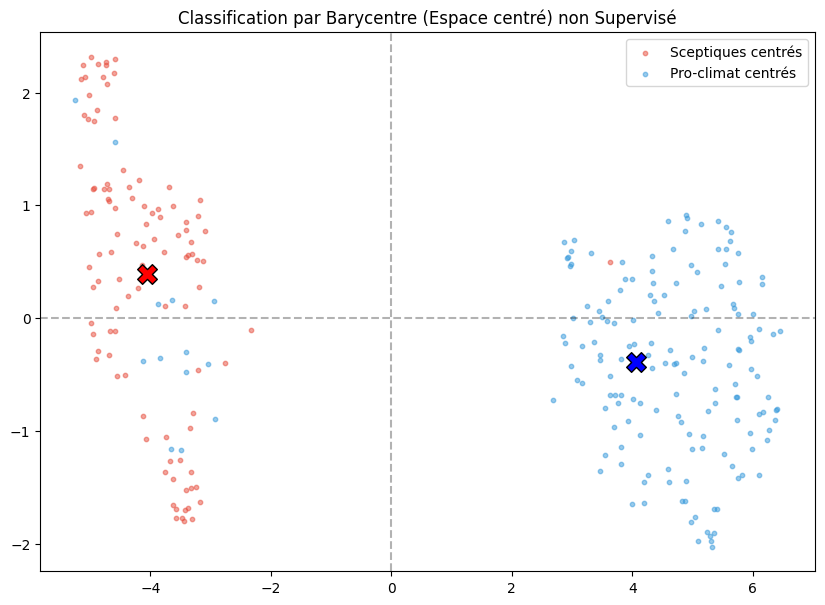

In [36]:
# 4. VISUALISATION
plt.figure(figsize=(10, 7))
plt.scatter(points_scep_Usup[:,0] - centre_global[0], points_scep_Usup[:,1] - centre_global[1], 
            c='#e74c3c', s=10, alpha=0.5, label='Sceptiques centrés')
plt.scatter(points_pro_Usup[:,0] - centre_global[0], points_pro_Usup[:,1] - centre_global[1], 
            c='#3498db', s=10, alpha=0.5, label='Pro-climat centrés')

# Affichage des centres
plt.scatter(bary_scep_c_Usup[0], bary_scep_c_Usup[1], c='red', marker='X', s=200, edgecolors='black')
plt.scatter(bary_pro_c_Usup[0], bary_pro_c_Usup[1], c='blue', marker='X', s=200, edgecolors='black')

plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Classification par Barycentre (Espace centré) non Supervisé")
plt.legend()
plt.show()

In [37]:
predictions = []
for point in test_emb:
    predictions.append(predire_classe(point, bary_scepu_Usup, bary_pro_Usup))

predictions = np.array(predictions)


nb_correct = np.sum(predictions == test_opinions_np)
accuracy_manuelle = nb_correct / len(test_opinions_np)

print(f"Nombre de points bien classés : {nb_correct} sur {len(test_opinions_np)}")
print(f"Précision manuelle : {accuracy_manuelle * 100:.2f}%")

Nombre de points bien classés : 68 sur 69
Précision manuelle : 98.55%


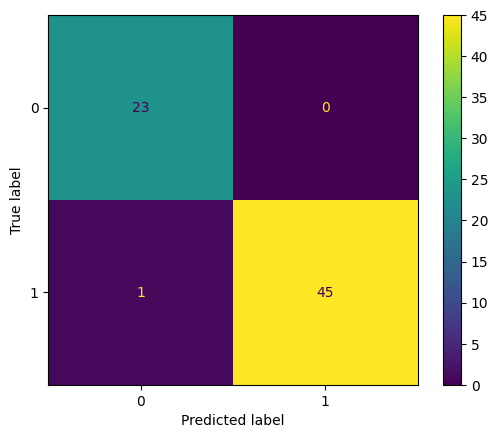

In [38]:
cm=confusion_matrix(test_opinions_np,predictions)
d3=ConfusionMatrixDisplay(cm)
d3.plot()